# Crop Recommendation Model — Karnataka

*Author:* R Megha Ganesh, BE ECE, DSCE Bangalore  
*Dataset:* Karnataka Crop Advisory Dataset (V2) — 21,960 rows, 39 crops  

---

Built this as part of our BE project. The idea is simple — farmer inputs soil
sensor readings, and the model recommends the best crop for that district and season.

We tried a few models (KNN, Decision Tree, Random Forest) and RF gave the best
results so we went with that. This notebook shows the full pipeline.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

np.random.seed(42)

df = pd.read_csv('karnataka_crop_dataset_V2.csv')
print("Dataset loaded:", df.shape)
print("Crops:", df['label'].nunique())
print("Districts:", df['district'].nunique())

Dataset loaded: (21960, 12)
Crops: 39
Districts: 31


## 1. Preprocessing

Categorical columns (soil_type, season, district, region) need to be
label encoded before feeding into the model.
Saving the encoders separately so we can use them during prediction too.

In [2]:
df_model = df.copy()

# encoding categorical columns, saving encoders for later use in prediction
encoders = {}
cat_cols = ['soil_type', 'season', 'district', 'region']

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le
    print(f"  {col}: {le.classes_.tolist()}")

X = df_model.drop('label', axis=1)
y = df_model['label']

print("\nFeatures:", X.columns.tolist())
print("Target classes:", y.nunique())

  soil_type: ['Alluvial', 'Black', 'Laterite', 'Loamy', 'Red', 'Sandy']
  season: ['Kharif', 'Rabi', 'Zaid']
  district: ['Bagalkote', 'Ballari', 'Belagavi', 'Bengaluru Rural', 'Bengaluru Urban', 'Bidar', 'Chamarajanagara', 'Chikkaballapura', 'Chikkamagaluru', 'Chitradurga', 'Dakshina Kannada', 'Davanagere', 'Dharwad', 'Gadag', 'Hassan', 'Haveri', 'Kalaburagi', 'Kodagu', 'Kolar', 'Koppala', 'Mandya', 'Mysuru', 'Raichur', 'Ramanagara', 'Shivamogga', 'Tumakuru', 'Udupi', 'Uttara Kannada', 'Vijayanagara', 'Vijayapura', 'Yadgir']
  region: ['Coastal Karnataka', 'Malnad', 'North Karnataka', 'South Karnataka']

Features: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'soil_type', 'season', 'district', 'region']
Target classes: 39


## 2. Train / Test Split + Model Training

Using 80/20 split with stratify so all 39 crops are represented in both
train and test sets proportionally.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} rows")
print(f"Test size:  {X_test.shape[0]} rows")

# n_estimators=100 worked well, tried 200 but barely any difference
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc*100:.2f}%")

Train size: 17568 rows
Test size:  4392 rows

Test Accuracy: 91.33%


## 3. Results

              precision    recall  f1-score   support

    arecanut       0.78      0.90      0.84       168
       bajra       0.98      0.88      0.92        56
      banana       0.87      1.00      0.93       240
   blackgram       0.69      0.75      0.72        56
    cardamom       0.86      0.75      0.80        96
      cashew       1.00      1.00      1.00       120
    chickpea       0.93      0.83      0.88        64
      chilli       0.86      0.90      0.88       128
     coconut       0.88      0.76      0.82       240
      coffee       0.93      0.96      0.95       120
      cotton       0.97      0.95      0.96       104
      ginger       0.62      0.85      0.72        48
      grapes       1.00      0.98      0.99        56
   groundnut       1.00      1.00      1.00       184
       guava       0.92      0.80      0.86       152
   horsegram       1.00      1.00      1.00        72
       jowar       0.95      0.99      0.97       168
 kidneybeans       0.98    

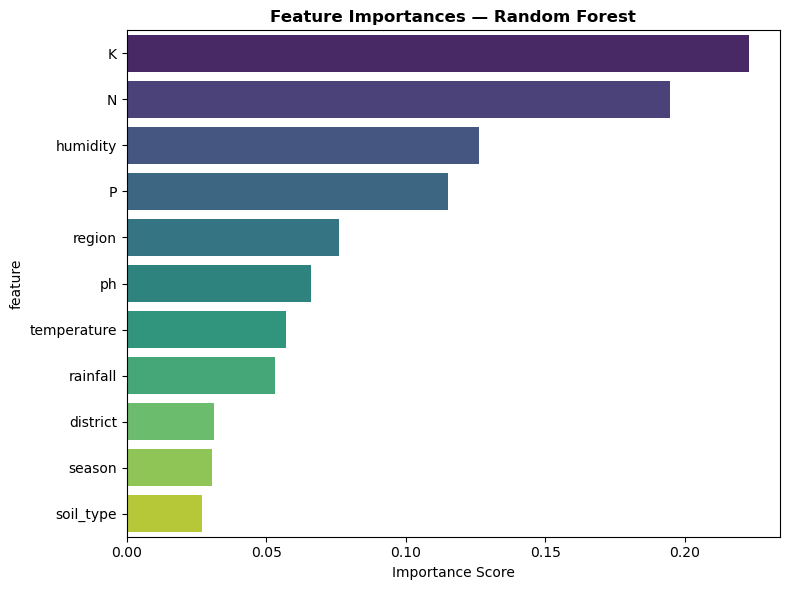

    feature  importance
          K    0.222900
          N    0.194626
   humidity    0.126245
          P    0.115240
     region    0.076039
         ph    0.066172
temperature    0.057195
   rainfall    0.052945
   district    0.031257
     season    0.030427
  soil_type    0.026955


In [6]:
# classification report shows per-crop precision and recall
# useful to spot if any crop is being misclassified often
print(classification_report(y_test, y_pred))
# feature importance — K and N dominate which makes sense agronomically
fi = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(x='importance', y='feature', data=fi,
            palette='viridis', ax=ax)
ax.set_title('Feature Importances — Random Forest', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

print(fi.to_string(index=False))

## 4. Live Prediction — Simulating Sensor Input

This is how the model would actually be used in the field.
ESP32 reads temperature + humidity from DHT22, soil moisture and NPK
from soil sensors, and sends values to this model for recommendation.

In [7]:
# simulating what our ESP32 + DHT22 + soil sensor would send
# values are realistic for Hassan district, Kharif season

sensor_reading = {
    'N':           45.0,   # soil NPK sensor (kg/ha)
    'P':           28.0,
    'K':           38.0,
    'temperature': 26.5,   # DHT22
    'humidity':    78.2,   # DHT22
    'ph':          6.3,    # pH sensor
    'rainfall':    380.0,  # rain gauge / IMD API (mm)
    'soil_type':   'Loamy',
    'season':      'Kharif',
    'district':    'Hassan',
    'region':      'Malnad'
}

# encode using the same encoders from training
row = sensor_reading.copy()
for col in cat_cols:
    row[col] = encoders[col].transform([row[col]])[0]

input_df = pd.DataFrame([row])
prediction = rf.predict(input_df)[0]
probs = rf.predict_proba(input_df)[0]

top3 = sorted(zip(rf.classes_, probs), key=lambda x: x[1], reverse=True)[:3]

print("=" * 38)
print("  SENSOR INPUT")
print("=" * 38)
for k, v in sensor_reading.items():
    print(f"  {k:<15}: {v}")
print("=" * 38)
print(f"  RECOMMENDED : {prediction.upper()}")
print("\n  Top 3:")
for i, (crop, prob) in enumerate(top3, 1):
    print(f"  {i}. {crop:<15} {prob*100:.1f}%")
print("=" * 38)

  SENSOR INPUT
  N              : 45.0
  P              : 28.0
  K              : 38.0
  temperature    : 26.5
  humidity       : 78.2
  ph             : 6.3
  rainfall       : 380.0
  soil_type      : Loamy
  season         : Kharif
  district       : Hassan
  region         : Malnad
  RECOMMENDED : RAGI

  Top 3:
  1. ragi            47.0%
  2. cashew          31.0%
  3. blackgram       14.0%


In [8]:
# saving the model — this is the same file used in our IoT pipeline
with open('crop_model_v2.pkl', 'wb') as f:
    pickle.dump(rf, f)

print("Model saved: crop_model_v2.pkl")
print(f"Final accuracy: {acc*100:.2f}%")
print(f"Crops covered: {y.nunique()}")
print(f"Districts covered: {df['district'].nunique()}")

Model saved: crop_model_v2.pkl
Final accuracy: 91.33%
Crops covered: 39
Districts covered: 31


## Summary

| | |
|---|---|
| Model | Random Forest (n=100) |
| Train/Test split | 80/20 stratified |
| Accuracy | 91.33% |
| Top feature | K (Potassium) |
| Crops | 39 |
| Districts | 31 |

The model performs well across most crops. Perennial crops like coffee,
cardamom and pepper have near-perfect precision since their
climate + district constraints are very specific.

*Limitations:*  
- Dataset is semi-synthetic — built from government source ranges,
  not direct field measurements  
- Does not account for market trends, water availability,
  or farmer preference  
- Socioeconomic factors are outside the scope of this model

*Next steps:*  
- Add yield prediction as a second model  
- Deploy on ESP32 with MQTT pipeline  
- Validate with real field sensor data